# Visitor Behavior Analytics

## Objective

The goal of this notebook is to understand how visitors interact with the e-commerce platform, identify behavioral patterns throughout the shopping journey, quantify funnel drop-offs, discover valuable customer segments, and generate actionable insights to improve conversion and customer retention.


# Phase 1: Visitor Overview
## Business Question

Understand the overall composition of visitors on the platform.

Questions:
- How many visitors interacted with the website?
- How many only viewed products?
- How many showed purchase intent by adding to cart?
- How many completed a purchase?
- What is the average activity per visitor?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
events = pd.read_csv("events.csv")
product_dimension = pd.read_csv("product_dimension.csv")

In [3]:
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")
events

,timestamp,visitorid,event,itemid,transactionid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN
1,2015-06-02 05:50:14.164,992329,view,248676,NaN
2,2015-06-02 05:13:19.827,111016,view,318965,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN
4,2015-06-02 05:02:17.106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,2015-08-01 03:13:05.939,591435,view,261427,NaN
2756097,2015-08-01 03:30:13.142,762376,view,115946,NaN
2756098,2015-08-01 02:57:00.527,1251746,view,78144,NaN
2756099,2015-08-01 03:08:50.703,1184451,view,283392,NaN


In [4]:
# Total unique visitors
total_visitors = events["visitorid"].nunique()
total_visitors

1407580

In [5]:
# Visitors who viewed
view_visitors = (events.loc[events["event"] == "view", "visitorid"].nunique())
view_visitors

1404179

In [6]:
# Visitors who added to cart
cart_visitors = (events.loc[events["event"] == "addtocart", "visitorid"].nunique())
cart_visitors

37722

In [7]:
# Visitors who purchased
buyer_visitors = events.loc[events["event"] == "transaction", "visitorid"].nunique()
buyer_visitors

11719

In [8]:
# Total events
total_events = len(events)
total_events

2756101

In [9]:
# Average events per visitor
avg_events = round(total_events / total_visitors, 2)
avg_events

1.96

In [10]:
visitor_summary = pd.DataFrame({"Metric":["Total Visitors","View Visitors","Cart Visitors","Buyer Visitors","Average Events per Visitor"],
    "Value":[
        total_visitors,
        view_visitors,
        cart_visitors,
        buyer_visitors,
        avg_events]})

visitor_summary

,Metric,Value
0,Total Visitors,1407580.00
1,View Visitors,1404179.00
2,Cart Visitors,37722.00
3,Buyer Visitors,11719.00
4,Average Events per Visitor,1.96


In [11]:
#Visitor Event Distribution
visitor_events = events.groupby("visitorid").size().reset_index(name="events")

visitor_events

,visitorid,events
0,0,3
1,1,1
2,2,8
3,3,1
4,4,1
...,...,...
1407575,1407575,1
1407576,1407576,1
1407577,1407577,1
1407578,1407578,1


In [12]:
visitor_events.describe()

,visitorid,events
count,1.407580e+06,1.407580e+06
mean,7.037895e+05,1.958042e+00
std,4.063335e+05,1.258049e+01
min,0.000000e+00,1.000000e+00
25%,3.518948e+05,1.000000e+00
50%,7.037895e+05,1.000000e+00
75%,1.055684e+06,2.000000e+00
max,1.407579e+06,7.757000e+03


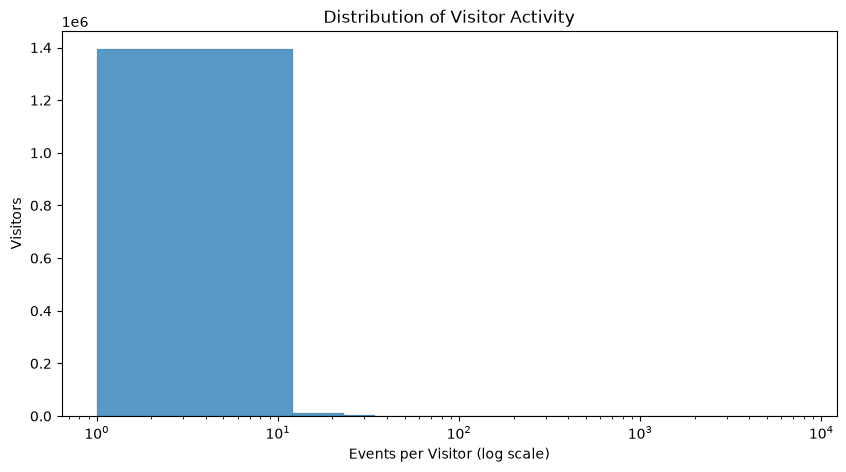

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(visitor_events["events"], bins=700)

plt.xscale("log")

plt.xlabel("Events per Visitor (log scale)")
plt.ylabel("Visitors")
plt.title("Distribution of Visitor Activity")

plt.show()

<Axes: ylabel='events'>

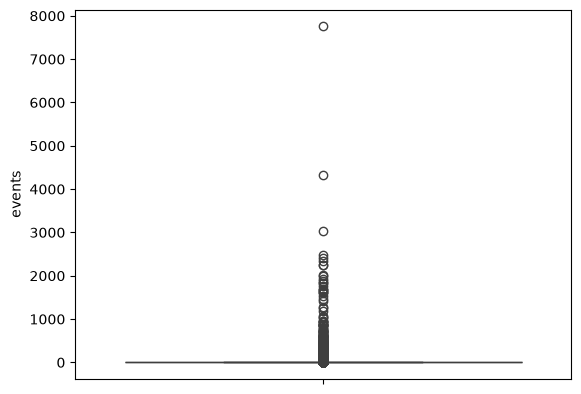

In [14]:
sns.boxplot(visitor_events["events"])

<Axes: xlabel='events'>

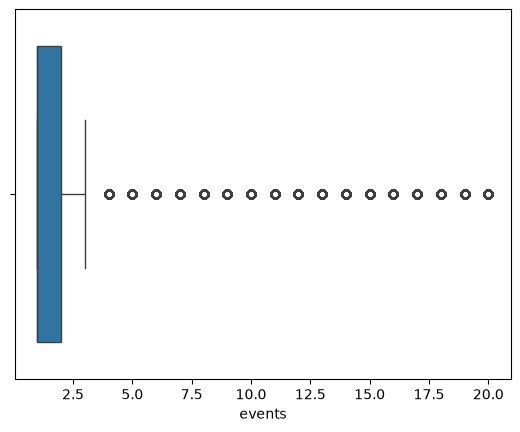

In [15]:
sns.boxplot(x=visitor_events.loc[visitor_events["events"] <= 20, "events"])

In [16]:
visitor_rates = pd.DataFrame({
    "Metric": [
        "View Visitors",
        "Cart Visitors",
        "Buyer Visitors"
    ],
    "Percentage": [
        round(view_visitors / total_visitors * 100, 2),
        round(cart_visitors / total_visitors * 100, 2),
        round(buyer_visitors / total_visitors * 100, 2)
    ]
})

visitor_rates

,Metric,Percentage
0,View Visitors,99.76
1,Cart Visitors,2.68
2,Buyer Visitors,0.83


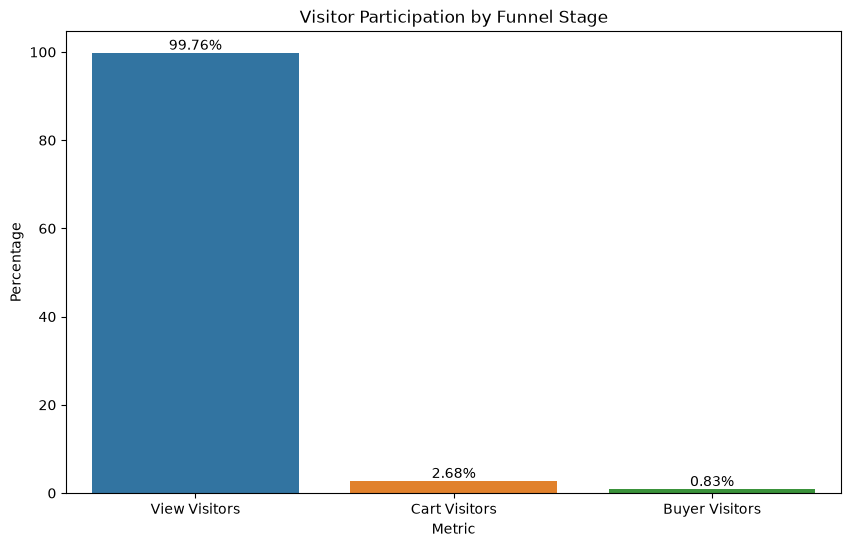

In [17]:
# visitor summary
plt.figure(figsize=(10,6))

ax = sns.barplot(data=visitor_rates,x="Metric",y="Percentage",hue='Metric')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.ylabel("Percentage")
plt.title("Visitor Participation by Funnel Stage")
plt.savefig('Visitor Participation by Funnel Stage.png',dpi=400)
plt.show()

# Phase 1: Visitor Overview

## Key Findings

- The platform recorded **1,407,580 unique visitors** during the observation period.
- Nearly **99.8%** of visitors viewed at least one product, indicating strong product discovery.
- Only **2.68%** of visitors added an item to their cart, revealing a significant drop-off between browsing and purchase intent.
- Just **0.83%** of visitors completed a purchase, highlighting a very low overall conversion rate.
- Visitors generated an average of **1.96 events per user**, suggesting that most users interacted with only one or two products before leaving.

## Visitor Activity Distribution

- The median visitor generated only **1 event**.
- 75% of visitors performed **2 or fewer events**.
- A small group of highly active users generated thousands of interactions (maximum: **7,757 events**), creating a highly right-skewed distribution.

## Business Insights

- Product discovery is **not the primary issue**, as almost every visitor views products.
- The largest loss occurs between **viewing products and adding them to the cart**, making this the biggest optimization opportunity.
- A very small percentage of highly engaged users contributes disproportionately to platform activity.
- The platform should focus on improving product pages, recommendations, pricing visibility, trust signals, and checkout incentives to convert browsers into buyers.

# Phase 2: Visitor Funnel Analysis
## Business Question

Understand how visitors progress through the purchase journey and identify the largest drop-off points.

Questions:
- How many visitors viewed products?
- How many visitors added products to cart?
- How many visitors completed a purchase?
- What is the visitor conversion rate between each stage?

In [18]:
# Unique visitors at each stage

visitor_funnel = pd.DataFrame({"Stage": ["Visitors","Viewed","Added to Cart","Purchased"],
    "Users": [total_visitors,view_visitors,cart_visitors,buyer_visitors]})

visitor_funnel

,Stage,Users
0,Visitors,1407580
1,Viewed,1404179
2,Added to Cart,37722
3,Purchased,11719


In [19]:
# funnel conversion
visitor_funnel["Conversion_from_Previous_%"] = (visitor_funnel["Users"].pct_change().add(1).mul(100)).round(2)
#add(1)- conversion to change
visitor_funnel.loc[0,"Conversion_from_Previous_%"] = 100
visitor_funnel["Conversion_from_Start_%"] = round(visitor_funnel["Users"] / total_visitors * 100, 2)

visitor_funnel

,Stage,Users,Conversion_from_Previous_%,Conversion_from_Start_%
0,Visitors,1407580,100.00,100.00
1,Viewed,1404179,99.76,99.76
2,Added to Cart,37722,2.69,2.68
3,Purchased,11719,31.07,0.83


In [20]:
# visitor drop-off
visitor_funnel["Drop_off"] = (visitor_funnel["Users"].shift(1)- visitor_funnel["Users"])
#used shift(1) to align each funnel stage with its previous stage
visitor_funnel

,Stage,Users,Conversion_from_Previous_%,Conversion_from_Start_%,Drop_off
0,Visitors,1407580,100.00,100.00,NaN
1,Viewed,1404179,99.76,99.76,3401.0
2,Added to Cart,37722,2.69,2.68,1366457.0
3,Purchased,11719,31.07,0.83,26003.0


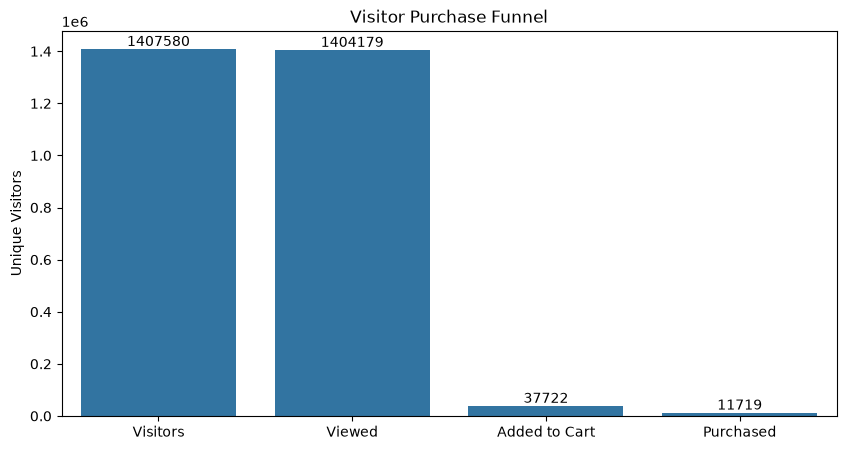

In [21]:
# funnel visualization
plt.figure(figsize=(10,5))

ax = sns.barplot(data=visitor_funnel,x="Stage",y="Users")

for container in ax.containers:
    ax.bar_label(container, fmt='%0.f')

plt.title("Visitor Purchase Funnel")
plt.ylabel("Unique Visitors")
plt.xlabel("")
plt.savefig('Visitor Purchase Funnel.png',dpi=400)

plt.show()

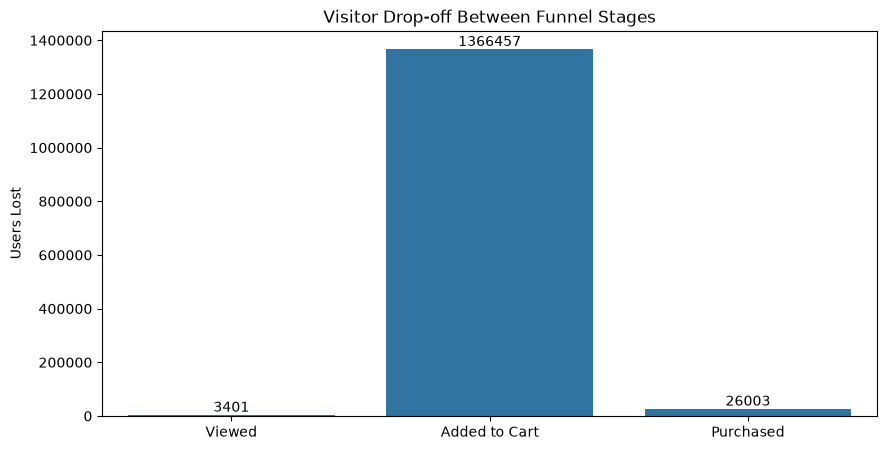

In [22]:
#Drop-off Visualization
dropoff = visitor_funnel.iloc[1:].copy()

plt.figure(figsize=(10,5))

ax=sns.barplot(data=dropoff,x="Stage",y="Drop_off")
for container in ax.containers:
    ax.bar_label(container, fmt='%0.f')

plt.title("Visitor Drop-off Between Funnel Stages")
plt.ylabel("Users Lost")
plt.xlabel("")
plt.ticklabel_format(style='plain', axis='y')
plt.savefig('Visitor Drop-off Between Funnel Stages.png',dpi=400)
plt.show()

 # Phase 2: Visitor Funnel Analysis

## Key Findings

- The platform attracted **1.41 million unique visitors**, and **99.76%** of them viewed at least one product, indicating that product discovery is not a major issue.
- The biggest leakage occurred between the **View → Add to Cart** stage, where only **2.69%** of viewers added a product to their cart.
- More than **1.36 million visitors** viewed products but left without showing purchase intent, making this the largest optimization opportunity in the customer journey.
- Once users reached the cart stage, **31.07%** successfully completed a purchase, suggesting that purchase intent is relatively strong after cart creation.
- The overall visitor-to-purchase conversion rate was only **0.83%**, highlighting substantial room for improving end-to-end conversion.

## Business Insights

- **Top Funnel is Healthy:** Nearly every visitor interacts with products, indicating that traffic quality and product visibility are strong.
- **Primary Bottleneck:** The largest drop-off occurs before users add products to the cart. This suggests potential issues with product attractiveness, pricing, product information, trust signals, or call-to-action effectiveness.
- **Checkout Performs Better:** Compared with the View → Cart stage, the Cart → Purchase conversion rate is relatively healthy (31%), implying that checkout friction is not the primary business problem.
- **Highest Business Impact:** Even a small improvement in the View → Cart conversion rate could significantly increase overall purchases because of the large volume of visitors at the top of the funnel.
- **Optimization Priority:** Focus on improving product pages, recommendation systems, pricing strategy, promotional offers, reviews, and user experience to encourage more visitors to add products to their carts.

# Phase 3: Visitor Segmentation

## Business Questions

- How many visitors only browse products?
- How many visitors add items to the cart but never purchase?
- How many visitors complete purchases?
- Which visitor segment is the largest?
- Where is the biggest opportunity for improving conversions?

In [23]:
#Create visitor-event table
visitor_events = events.groupby(["visitorid", "event"]).size().unstack(fill_value=0)

visitor_events

event,addtocart,transaction,view
visitorid,,,
0,0,0,3
1,0,0,1
2,0,0,8
3,0,0,1
4,0,0,1
...,...,...,...
1407575,0,0,1
1407576,0,0,1
1407577,0,0,1


In [24]:
#Create Visitor Segments
visitor_events["Segment"] = "Other"

# Buyers
visitor_events.loc[visitor_events["transaction"] > 0,"Segment"] = "Buyer"

# Cart Abandoners
visitor_events.loc[(visitor_events["transaction"] == 0) &(visitor_events["addtocart"] > 0),"Segment"] = "Cart Abandoner"

# Browsers
visitor_events.loc[(visitor_events["transaction"] == 0) &(visitor_events["addtocart"] == 0) &(visitor_events["view"] > 0),"Segment"] = "Browser"

In [25]:
visitor_segments = visitor_events["Segment"].value_counts().rename_axis("Segment").reset_index(name="Visitors")

visitor_segments

,Segment,Visitors
0,Browser,1368715
1,Cart Abandoner,27146
2,Buyer,11719


In [26]:
# percentage visitor segments-
visitor_segments["Percentage"] = round(visitor_segments["Visitors"]/ visitor_segments["Visitors"].sum()*100,2)

visitor_segments

,Segment,Visitors,Percentage
0,Browser,1368715,97.24
1,Cart Abandoner,27146,1.93
2,Buyer,11719,0.83


/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_32087/2283721016.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=visitor_segments,x="Segment",y="Visitors", palette='icefire')


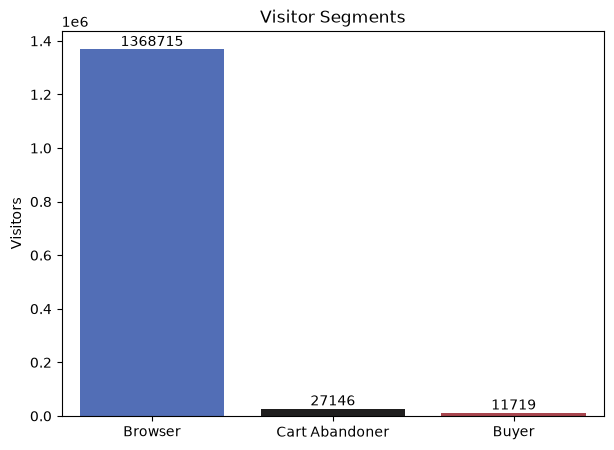

In [27]:
# visualization-
plt.figure(figsize=(7,5))

ax = sns.barplot(data=visitor_segments,x="Segment",y="Visitors", palette='icefire')
for container in ax.containers:
    ax.bar_label(container,fmt='%.0f')
plt.title("Visitor Segments")
plt.ylabel("Visitors")
plt.xlabel("")
plt.show()

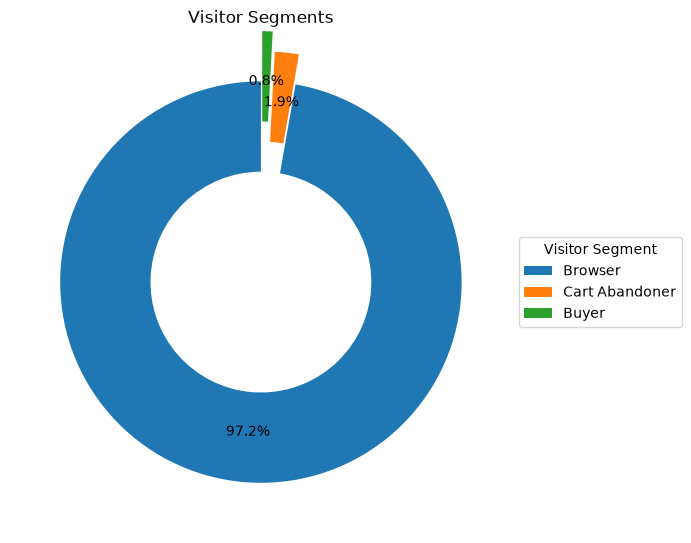

In [28]:
plt.figure(figsize=(7,7))
explode = [0, 0.15, 0.25] 

plt.pie(visitor_segments["Visitors"],labels=None,autopct="%1.1f%%",startangle=90,pctdistance=0.75,
    wedgeprops=dict(width=0.45),explode=explode)
plt.legend(visitor_segments["Segment"],title="Visitor Segment",loc="center left",bbox_to_anchor=(1.0, 0.5))


plt.title("Visitor Segments")
plt.tight_layout()
plt.savefig('Visitor Segments.png',dpi=400)

plt.show()

## Phase 3: Visitor Segmentation

### Visitor Distribution

| Segment | Visitors | Percentage |
|---------|----------:|-----------:|
| Browser | 1,368,715 | 97.24% |
| Cart Abandoner | 27,146 | 1.93% |
| Buyer | 11,719 | 0.83% |

### Business Insights

- **97.24%** of visitors are **Browsers**, indicating that while the platform attracts significant traffic, most users leave without showing purchase intent.
- **1.93%** of visitors become **Cart Abandoners**, demonstrating purchase interest but failing to complete checkout. This segment represents the most valuable audience for remarketing campaigns.
- Only **0.83%** of visitors complete a purchase, highlighting substantial room for improving the overall conversion funnel.
- The distribution suggests that increasing the **Browser → Cart** and **Cart → Purchase** conversion rates would have a much greater business impact than simply acquiring more traffic.

### Business Recommendations

- Improve product pages with better descriptions, reviews, pricing transparency, and personalized recommendations to encourage browsers to add products to the cart.
- Launch abandoned-cart recovery campaigns using email reminders, push notifications, or limited-time discounts.
- Optimize the checkout experience by reducing friction, simplifying forms, and providing clear shipping and payment information.
- Personalize product recommendations based on browsing behavior to improve visitor engagement and increase purchase probability.

# Phase 4: Purchase Behavior Analysis
## Business Questions
- How do customers actually buy?
- How many visitors purchased multiple times?
- How many products does a buyer purchase?
- Which visitors generate the most purchases?

In [29]:
# Purchase Events-
purchases = events[events["event"] == "transaction"].copy()
purchases

,timestamp,visitorid,event,itemid,transactionid
130,2015-06-02 05:17:56.276,599528,transaction,356475,4000.0
304,2015-06-01 21:18:20.981,121688,transaction,15335,11117.0
418,2015-06-01 21:25:15.008,552148,transaction,81345,5444.0
814,2015-06-01 16:38:56.375,102019,transaction,150318,13556.0
843,2015-06-01 16:01:58.180,189384,transaction,310791,7244.0
...,...,...,...,...,...
2755294,2015-07-31 21:12:56.570,1050575,transaction,31640,8354.0
2755349,2015-07-31 21:57:58.779,861299,transaction,456602,3643.0
2755508,2015-07-31 15:48:50.123,855941,transaction,235771,4385.0
2755603,2015-07-31 15:12:40.300,548772,transaction,29167,13872.0


In [30]:
# Buyer Statistics
buyer_stats = purchases.groupby("visitorid").agg(purchases=("itemid", "count"),unique_products=("itemid", "nunique")).reset_index()

buyer_stats

,visitorid,purchases,unique_products
0,172,2,2
1,186,1,1
2,264,2,2
3,419,1,1
4,539,1,1
...,...,...,...
11714,1406787,1,1
11715,1406981,1,1
11716,1407070,1,1
11717,1407110,1,1


In [31]:
#overview-
summary = pd.DataFrame({"Metric":["Total Buyers","Total Purchases","Average Purchases per Buyer","Median Purchases",
        "Average Unique Products"],
    "Value":[
        buyer_stats["visitorid"].nunique(),
        buyer_stats["purchases"].sum(),
        round(buyer_stats["purchases"].mean(),2),
        buyer_stats["purchases"].median(),
        round(buyer_stats["unique_products"].mean(),2)]})

summary

,Metric,Value
0,Total Buyers,11719.00
1,Total Purchases,22457.00
2,Average Purchases per Buyer,1.92
3,Median Purchases,1.00
4,Average Unique Products,1.82


In [32]:
# One-Time vs Repeat Buyers
buyer_stats["Buyer_Type"] = np.where( buyer_stats["purchases"] == 1,"One-Time","Repeat")

buyer_segment = buyer_stats["Buyer_Type"].value_counts().reset_index()

buyer_segment.columns = ["Buyer Type", "Buyers"]
buyer_segment

,Buyer Type,Buyers
0,One-Time,9143
1,Repeat,2576


In [33]:
buyer_segment["Percentage"] = round(buyer_segment["Buyers"] /buyer_segment["Buyers"].sum() * 100, 2)

buyer_segment

,Buyer Type,Buyers,Percentage
0,One-Time,9143,78.02
1,Repeat,2576,21.98


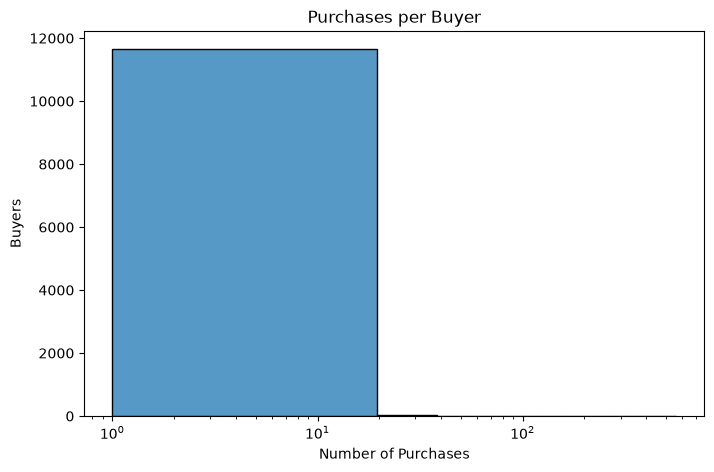

In [34]:
# Purchase Distribution-
plt.figure(figsize=(8,5))

sns.histplot(buyer_stats["purchases"],bins=30)

plt.title("Purchases per Buyer")
plt.xlabel("Number of Purchases")
plt.ylabel("Buyers")
plt.xscale('log')

plt.show()

In [35]:
buyer_stats["purchases"].describe()

count    11719.000000
mean         1.916290
std          8.850529
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        559.000000
Name: purchases, dtype: float64

In [36]:
buyer_stats["unique_products"].describe()

count    11719.000000
mean         1.815001
std          8.347305
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        532.000000
Name: unique_products, dtype: float64

In [37]:
# users top 10 purchase frequency
buyer_stats["purchases"].value_counts().head(10)

purchases
1     9143
2     1549
3      435
4      215
5       83
6       67
8       27
7       26
10      20
9       16
Name: count, dtype: int64

In [38]:
# generally how much unique products user buy-
buyer_stats["unique_products"].value_counts().head(10)

unique_products
1     9545
2     1289
3      386
4      170
5       80
6       47
7       22
10      20
9       18
8       17
Name: count, dtype: int64

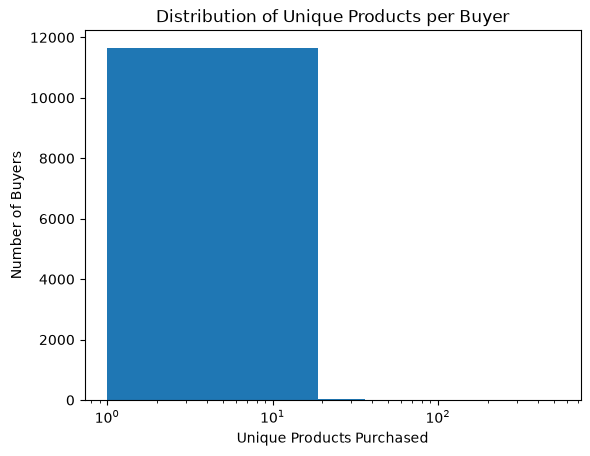

In [39]:
buyer_stats["unique_products"].hist(bins=30)
plt.xlabel("Unique Products Purchased")
plt.ylabel("Number of Buyers")
plt.title("Distribution of Unique Products per Buyer")
plt.xscale('log')
plt.grid(None)
plt.show()

In [40]:
# Percentage of buyers who purchased only one unique product

one_product_buyers = (buyer_stats["unique_products"] == 1).sum()

total_buyers = len(buyer_stats)

percentage = round((one_product_buyers / total_buyers) * 100, 2)

#round(buyer_stats["unique_products"] == 1).mean()*100,2)

print(f"Buyers purchasing only one unique product: {one_product_buyers:,}")
print(f"Percentage: {percentage}%")

Buyers purchasing only one unique product: 9,545
Percentage: 81.45%


In [41]:
#Repeat purchase rate
repeat_purchase_pct = round((buyer_stats["purchases"] > 1).mean()*100,2)
repeat_purchase_pct

np.float64(21.98)

In [42]:
#Repeat product rate
repeat_same_product = buyer_stats[(buyer_stats["purchases"] > buyer_stats["unique_products"])]

repeat_same_product.shape[0]

650

In [43]:
(buyer_stats["purchases"] > buyer_stats["unique_products"]).mean()*100

np.float64(5.546548340302074)

In [44]:
#Basket Size Distribution-
buyer_stats["unique_products"].value_counts(normalize=True)*100

unique_products
1      81.448929
2      10.999232
3       3.293796
4       1.450636
5       0.682652
         ...    
26      0.008533
35      0.008533
56      0.008533
532     0.008533
84      0.008533
Name: proportion, Length: 70, dtype: float64

In [45]:
#Power Buyers
buyer_stats[buyer_stats["purchases"]>=5]

,visitorid,purchases,unique_products,Buyer_Type
131,17476,7,7,Repeat
135,17676,42,42,Repeat
168,21712,6,6,Repeat
177,22990,11,9,Repeat
308,38103,7,7,Repeat
...,...,...,...,...
11485,1376763,8,8,Repeat
11565,1385029,5,1,Repeat
11567,1385073,86,84,Repeat
11665,1398978,9,9,Repeat


In [46]:
#percentage of Power buyer
(buyer_stats["purchases"]>=5).mean()*100

np.float64(3.2169980373752023)

In [47]:
# percentage of Heavy Basket Buyers-
buyer_stats["unique_products"].ge(5).mean()*100

np.float64(2.8074067753221263)

## Buyer Loyalty & Basket Insights

| Metric | Value |
|--------|------:|
| Repeat Purchase Rate | **21.98%** |
| Buyers Reordering the Same Product | **650 buyers (5.55%)** |
| Buyers Purchasing Only One Unique Product | **81.45%** |
| Buyers Purchasing Two Unique Products | **11.00%** |
| Power Buyers (≥5 Purchases) | **3.22%** |
| Heavy Basket Buyers (≥5 Unique Products) | **2.81%** |

### Key Insights

- **21.98%** of buyers returned to make another purchase, while **78.02%** purchased only once.
- **81.45%** of buyers purchased only **one unique product**, indicating that most shopping sessions consist of a single-item purchase.
- Only **11.00%** of buyers purchased exactly **two unique products**, with the proportion decreasing sharply for larger baskets.
- **5.55%** of buyers reordered the **same product**, suggesting a small but valuable segment of repeat-demand customers.
- **Power Buyers (3.22%)** made **5 or more purchases**, representing a high-value customer segment despite their small size.
- **Heavy Basket Buyers (2.81%)** purchased **5 or more unique products**, indicating significant opportunities to improve basket size through cross-selling.

### Business Recommendations

- Increase **repeat purchases** through loyalty programs, personalized offers, and remarketing campaigns.
- Encourage **larger baskets** using product bundles, cross-selling, and "Frequently Bought Together" recommendations.
- Identify and nurture **Power Buyers**, as they are likely to contribute disproportionately to long-term revenue.
- Target **single-product buyers** with complementary product recommendations to improve average order value.

# Phase 5 — Cart Abandonment Analysis
## Business Questions-
- How many users abandoned their cart?
- Cart Abandonment Rate?
- Average products left in cart?
- Categories most frequently abandoned?

In [48]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [49]:
#Identify Cart Abandoners-

# Visitors who added at least one product to cart
cart_users = events.loc[events["event"] == "addtocart", "visitorid"].drop_duplicates()

# Visitors who completed at least one purchase
buyer_users = events.loc[events["event"] == "transaction", "visitorid"].drop_duplicates()

# Cart abandoners
cart_abandoners = cart_users[~cart_users.isin(buyer_users)]

cart_abandoners_count = len(cart_abandoners)

cart_abandoners_count

27146

In [50]:
#Cart Abandonment Rate
cart_abandonment_rate = round(len(cart_abandoners) / len(cart_users) * 100,2)

cart_abandonment_rate

71.96

In [51]:
#Build Abandoner Dataset
abandoned_events = events[events["visitorid"].isin(cart_abandoners)].copy()
abandoned_events

,timestamp,visitorid,event,itemid,transactionid
17,2015-06-02 05:33:56.124,287857,addtocart,5206,NaN
22,2015-06-02 05:01:14.809,1213673,view,343861,NaN
62,2015-06-02 05:51:43.386,503970,view,448136,NaN
63,2015-06-02 05:39:03.021,1193904,addtocart,255275,NaN
80,2015-06-02 05:39:47.786,77112,view,97879,NaN
...,...,...,...,...,...
2756071,2015-08-01 03:49:10.177,916871,view,233369,NaN
2756074,2015-08-01 03:49:54.744,144106,addtocart,141241,NaN
2756078,2015-08-01 03:30:07.937,804736,addtocart,447661,NaN
2756088,2015-08-01 03:35:47.472,831605,view,57810,NaN


In [52]:
#Average Products Left in Cart
cart_size = abandoned_events[abandoned_events["event"]=="addtocart"].groupby("visitorid")["itemid"].nunique()
cart_size.describe()

count    27146.000000
mean         1.403043
std          1.914793
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        117.000000
Name: itemid, dtype: float64

In [53]:
avg_cart_size = round(cart_size.mean(),2)

avg_cart_size

np.float64(1.4)

In [54]:
#Most Frequently Abandoned Categories-
abandoned_cart = (abandoned_events[abandoned_events["event"]=="addtocart"].merge(
        product_dimension[["itemid","categoryid"]],
        on="itemid",
        how="left"))
abandoned_cart

,timestamp,visitorid,event,itemid,transactionid,categoryid
0,2015-06-02 05:33:56.124,287857,addtocart,5206,NaN,381.0
1,2015-06-02 05:39:03.021,1193904,addtocart,255275,NaN,1002.0
2,2015-06-02 04:54:40.956,105775,addtocart,312728,NaN,1098.0
3,2015-06-01 21:42:49.716,196602,addtocart,63312,NaN,491.0
4,2015-06-02 04:44:14.274,56229,addtocart,115244,NaN,1649.0
...,...,...,...,...,...,...
41860,2015-08-01 03:40:00.805,831605,addtocart,57810,NaN,1625.0
41861,2015-08-01 03:02:36.086,10670,addtocart,419736,NaN,333.0
41862,2015-08-01 03:49:54.744,144106,addtocart,141241,NaN,1322.0
41863,2015-08-01 03:30:07.937,804736,addtocart,447661,NaN,1477.0


In [55]:
abandoned_categories = abandoned_cart["categoryid"].value_counts().reset_index()

abandoned_categories.columns = [ "Category","Abandoned_Carts"]

abandoned_categories.head(20)

,Category,Abandoned_Carts
0,491.0,1205
1,1051.0,1146
2,959.0,1015
3,1483.0,984
4,342.0,894
5,683.0,655
6,1279.0,547
7,858.0,493
8,84.0,485
9,1135.0,462


/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_32087/4167716587.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=abandoned_categories.head(10),y="Abandoned_Carts",x=ct.head(10),palette='Reds_r')


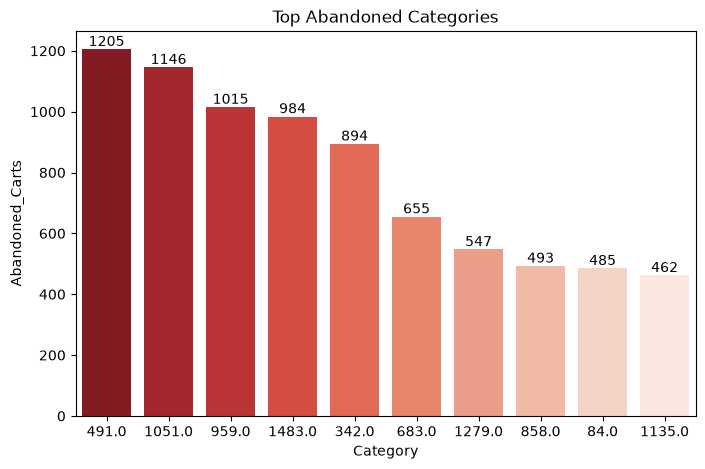

In [56]:
plt.figure(figsize=(8,5))
abandoned_categories = abandoned_categories.sort_values("Abandoned_Carts",ascending=False)

ct=abandoned_categories['Category'].astype(str)

ax=sns.barplot(data=abandoned_categories.head(10),y="Abandoned_Carts",x=ct.head(10),palette='Reds_r')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top Abandoned Categories")
plt.savefig('Top Abandoned Categories.png',dpi=400)

plt.show()

## Phase 5: Cart Abandonment Analysis

### Objective
Analyze visitors who added products to their cart but did not complete a purchase. This helps identify revenue leakage and highlights opportunities to improve the checkout funnel.

---

### Overall Cart Abandonment

| Metric | Value |
|--------|------:|
| Cart Visitors | 37,722 |
| Cart Abandoners | 27,146 |
| Cart Abandonment Rate | **71.96%** |

### Key Findings

- Nearly **72%** of visitors who added products to their cart did **not** complete a purchase.
- This indicates that the largest loss in the customer journey occurs **after the Add-to-Cart stage**, making checkout optimization a high-impact opportunity.

---

### Average Abandoned Cart Size

| Metric | Value |
|--------|------:|
| Average Products Left in Cart | **1.40** |
| Median Cart Size | **1** |
| Maximum Cart Size | **117** |

### Key Findings

- Most abandoned carts contain **only one product**.
- The average abandoned cart size is **1.4 products**, suggesting customers typically abandon purchases immediately after adding their first item rather than after building a large basket.
- A few extreme outliers abandoned very large carts, but these represent a very small portion of users.

---

### Most Frequently Abandoned Categories

| Category ID | Abandoned Carts |
|------------:|----------------:|
| 491 | 1,205 |
| 1051 | 1,146 |
| 959 | 1,015 |
| 1483 | 984 |
| 342 | 894 |
| 683 | 655 |
| 1279 | 547 |
| 858 | 493 |
| 84 | 485 |
| 1135 | 462 |

### Key Findings

- Categories **491**, **1051**, **959**, **1483**, and **342** account for the highest number of abandoned carts.
- Many of these categories were also among the **highest-traffic categories**, indicating strong customer interest but poor conversion after adding items to the cart.
- These categories should be prioritized for investigating pricing, product information, stock availability, shipping costs, or checkout friction.

---

### Business Insights

- The **checkout stage is the biggest point of customer drop-off**, with nearly three out of four cart users abandoning their purchase.
- Since most abandoned carts contain only **one product**, simplifying the buying experience immediately after the first Add-to-Cart action could significantly improve conversions.
- High-abandonment categories represent the **largest revenue recovery opportunity** because they already attract substantial customer demand.
- Potential interventions include:
  - Cart reminder emails or notifications
  - Limited-time discounts
  - Free shipping incentives
  - Simplified checkout flow
  - Better product information and trust signals
  - Price competitiveness analysis

# Phase 6 — Visitor Journey Analysis 

## This phase answers:

- How many products does a visitor view before purchasing?
- How many products does a visitor view before abandoning?
- How many categories does a visitor explore?
- Do buyers browse more than abandoners?
- How engaged are successful buyers?

In [57]:
#Visitor Event Summary
visitor_summary = (events.groupby("visitorid").agg(
        Views=("event", lambda x: (x=="view").sum()),
        Add_to_Cart=("event", lambda x: (x=="addtocart").sum()),
        Purchases=("event", lambda x: (x=="transaction").sum()),
        Unique_Products=("itemid","nunique")).reset_index())

visitor_summary

,visitorid,Views,Add_to_Cart,Purchases,Unique_Products
0,0,3,0,0,3
1,1,1,0,0,1
2,2,8,0,0,4
3,3,1,0,0,1
4,4,1,0,0,1
...,...,...,...,...,...
1407575,1407575,1,0,0,1
1407576,1407576,1,0,0,1
1407577,1407577,1,0,0,1
1407578,1407578,1,0,0,1


In [58]:
#Visitor Outcome
visitor_summary["Outcome"] = np.select([visitor_summary["Purchases"] > 0,visitor_summary["Add_to_Cart"] > 0],
    ["Buyer","Cart Abandoner"],default="Browser")

visitor_summary.head()

,visitorid,Views,Add_to_Cart,Purchases,Unique_Products,Outcome
0,0,3,0,0,3,Browser
1,1,1,0,0,1,Browser
2,2,8,0,0,4,Browser
3,3,1,0,0,1,Browser
4,4,1,0,0,1,Browser


In [59]:
#Compare User Types
visitor_summary.groupby("Outcome").agg(Visitors=("visitorid","count"),Avg_Views=("Views","mean"),
    Avg_Cart=("Add_to_Cart","mean"),
    Avg_Unique_Products=("Unique_Products","mean")).round(2)

,Visitors,Avg_Views,Avg_Cart,Avg_Unique_Products
Outcome,,,,
Browser,1368715,1.71,0.00,1.41
Buyer,11719,15.42,2.34,9.54
Cart Abandoner,27146,5.49,1.54,3.71


In [60]:
#Visualization
comparison = (visitor_summary.groupby("Outcome")[["Views","Add_to_Cart","Unique_Products"]].mean().round(2))

comparison

,Views,Add_to_Cart,Unique_Products
Outcome,,,
Browser,1.71,0.00,1.41
Buyer,15.42,2.34,9.54
Cart Abandoner,5.49,1.54,3.71


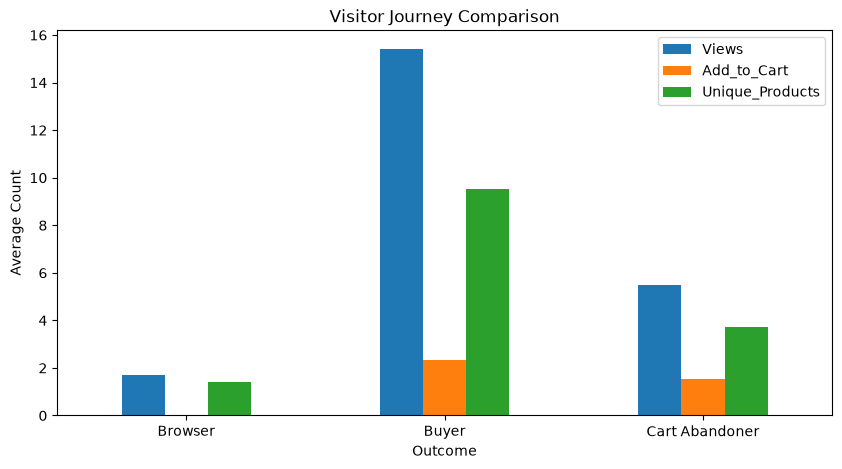

In [61]:
comparison.plot( kind="bar", figsize=(10,5))

plt.ylabel("Average Count")
plt.title("Visitor Journey Comparison")

plt.xticks(rotation=0)
plt.savefig('Visitor Journey Comparison.png',dpi=400)
plt.show()

In [62]:
# merge categories into events-
events_category = events.merge(product_dimension[["itemid","categoryid"]],on="itemid",how="left")
events_category

,timestamp,visitorid,event,itemid,transactionid,categoryid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN,1173.0
1,2015-06-02 05:50:14.164,992329,view,248676,NaN,1231.0
2,2015-06-02 05:13:19.827,111016,view,318965,NaN,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN,914.0
4,2015-06-02 05:02:17.106,951259,view,367447,NaN,491.0
...,...,...,...,...,...,...
2756096,2015-08-01 03:13:05.939,591435,view,261427,NaN,1623.0
2756097,2015-08-01 03:30:13.142,762376,view,115946,NaN,1616.0
2756098,2015-08-01 02:57:00.527,1251746,view,78144,NaN,969.0
2756099,2015-08-01 03:08:50.703,1184451,view,283392,NaN,1589.0


In [63]:
# unique categories per visitor
visitor_categories = events_category.groupby("visitorid").agg(Unique_Categories=("categoryid","nunique")).reset_index()
visitor_categories

,visitorid,Unique_Categories
0,0,3
1,1,1
2,2,2
3,3,1
4,4,0
...,...,...
1407575,1407575,1
1407576,1407576,1
1407577,1407577,1
1407578,1407578,1


In [64]:
# merge visitor category and visitor summary-
visitor_summary = visitor_summary.merge(visitor_categories,on="visitorid",how="left")
visitor_summary

,visitorid,Views,Add_to_Cart,Purchases,Unique_Products,Outcome,Unique_Categories
0,0,3,0,0,3,Browser,3
1,1,1,0,0,1,Browser,1
2,2,8,0,0,4,Browser,2
3,3,1,0,0,1,Browser,1
4,4,1,0,0,1,Browser,0
...,...,...,...,...,...,...,...
1407575,1407575,1,0,0,1,Browser,1
1407576,1407576,1,0,0,1,Browser,1
1407577,1407577,1,0,0,1,Browser,1
1407578,1407578,1,0,0,1,Browser,1


In [65]:
#Do buyers browse more than abandoners?
visitor_summary.groupby("Outcome").agg(Avg_Views=("Views","mean"),Avg_Unique_Products=("Unique_Products","mean"),
Avg_Unique_Categories=("Unique_Categories","mean")).round(2)

,Avg_Views,Avg_Unique_Products,Avg_Unique_Categories
Outcome,,,
Browser,1.71,1.41,0.98
Buyer,15.42,9.54,3.90
Cart Abandoner,5.49,3.71,1.78


In [66]:
# engagment of buyers
buyer_engagement = visitor_summary.groupby("Outcome").agg(

    Avg_Views=("Views","mean"),

    Avg_Add_to_Cart=("Add_to_Cart","mean"),

    Avg_Unique_Products=("Unique_Products","mean"),

    Avg_Unique_Categories=("Unique_Categories","mean"),

    Avg_Purchases=("Purchases","mean")

).round(2)

buyer_engagement

,Avg_Views,Avg_Add_to_Cart,Avg_Unique_Products,Avg_Unique_Categories,Avg_Purchases
Outcome,,,,,
Browser,1.71,0.00,1.41,0.98,0.00
Buyer,15.42,2.34,9.54,3.90,1.92
Cart Abandoner,5.49,1.54,3.71,1.78,0.00


## Phase 6: Visitor Journey Analysis

### Objective
Analyze how visitor behavior differs across Browsers, Cart Abandoners, and Buyers by comparing browsing depth, cart activity, product exploration, and category exploration.

---

### Visitor Journey Summary

| Outcome | Visitors | Avg Views | Avg Cart Adds | Avg Unique Products | Avg Unique Categories | Avg Purchases |
|---------|---------:|----------:|--------------:|--------------------:|----------------------:|--------------:|
| Browser | 1,368,715 | 1.71 | 0.00 | 1.41 | 0.98 | 0.00 |
| Buyer | 11,719 | 15.42 | 2.34 | 9.54 | 3.90 | 1.92 |
| Cart Abandoner | 27,146 | 5.49 | 1.54 | 3.71 | 1.78 | 0.00 |

---

### Key Findings

#### 1. How many products does a visitor view before purchasing?

- Buyers viewed **15.42 products on average** before making a purchase.
- Buyers browse nearly **9× more products** than casual browsers.

---

#### 2. How many products does a visitor view before abandoning?

- Cart abandoners viewed **5.49 products on average** before leaving.
- This indicates that abandoners are engaged users who actively explore products but fail to complete the purchase.

---

#### 3. How many categories does a visitor explore?

| Visitor Type | Avg Categories Explored |
|--------------|-----------------------:|
| Browser | 0.98 |
| Cart Abandoner | 1.78 |
| Buyer | 3.90 |

- Buyers explored nearly **4 categories** on average.
- Browsers generally remained within a single category.

---

#### 4. Do buyers browse more than abandoners?

Yes.

| Metric | Buyer | Cart Abandoner |
|--------|------:|---------------:|
| Avg Views | **15.42** | 5.49 |
| Avg Products | **9.54** | 3.71 |
| Avg Categories | **3.90** | 1.78 |

Buyers consistently browse significantly more products and categories before completing a purchase, indicating that successful purchases are associated with deeper product exploration.

---

#### 5. How engaged are successful buyers?

Successful buyers are the most engaged users on the platform.

- View **15.42 products** before purchasing.
- Add **2.34 products** to the cart on average.
- Explore **9.54 unique products**.
- Browse **3.90 categories**.
- Complete **1.92 purchases** on average.

---

### Business Insights

- Browsers exhibit shallow engagement, typically viewing only **1–2 products** before leaving.
- Cart abandoners represent **high-intent visitors**, exploring multiple products and adding items to their carts but failing to convert.
- Buyers spend considerably more time exploring products and categories, suggesting that deeper engagement strongly correlates with successful purchases.
- Increasing engagement among browsers and reducing friction for cart abandoners could significantly improve overall conversion rates.

# Phase 7: Category Preference by Visitor Type

## Business Questions

- Which categories are viewed mostly by browsers?
- Which categories attract buyers?
- Which categories have the highest cart abandonment?
- Which categories convert best?
- Which categories have high interest but low purchase intent?

In [67]:
#visitor-category dataset
visitor_category = events_category.merge(visitor_summary[["visitorid", "Outcome"]],on="visitorid",how="left")
visitor_category.head()

,timestamp,visitorid,event,itemid,transactionid,categoryid,Outcome
0,2015-06-02 05:02:12.117,257597,view,355908,NaN,1173.0,Browser
1,2015-06-02 05:50:14.164,992329,view,248676,NaN,1231.0,Browser
2,2015-06-02 05:13:19.827,111016,view,318965,NaN,NaN,Browser
3,2015-06-02 05:12:35.914,483717,view,253185,NaN,914.0,Browser
4,2015-06-02 05:02:17.106,951259,view,367447,NaN,491.0,Browser


In [68]:
#Category preference by visitor type
category_preference = visitor_category.groupby(["Outcome", "categoryid"]).size().reset_index(name="Interactions")

category_preference.head()

,Outcome,categoryid,Interactions
0,Browser,0.0,838
1,Browser,1.0,4759
2,Browser,3.0,2086
3,Browser,4.0,103
4,Browser,5.0,26368


In [69]:
#Top categories for each visitor type-
top_categories = category_preference.sort_values(["Outcome", "Interactions"],ascending=[True, False]).groupby("Outcome").head(10)

top_categories

,Outcome,categoryid,Interactions
674,Browser,1051.0,64378
957,Browser,1483.0,57242
321,Browser,491.0,54208
613,Browser,959.0,43297
222,Browser,342.0,41315
444,Browser,683.0,31748
821,Browser,1279.0,28626
4,Browser,5.0,26368
425,Browser,646.0,24559
32,Browser,48.0,24244


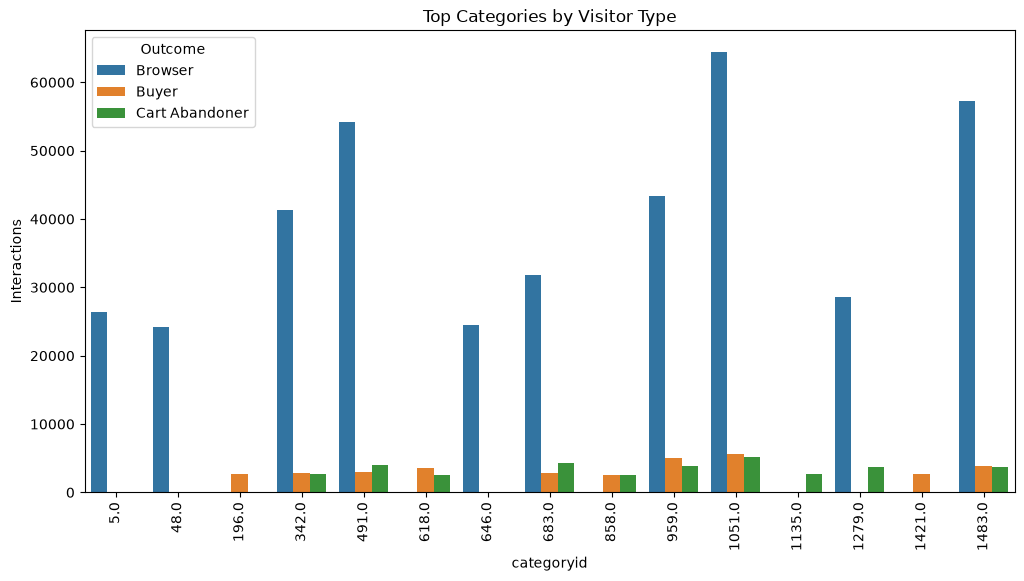

In [70]:
#visualization
plt.figure(figsize=(12,6))

sns.barplot(data=top_categories,x="categoryid",y="Interactions",hue="Outcome")

plt.xticks(rotation=90)

plt.title("Top Categories by Visitor Type")
plt.savefig('Top Categories by Visitor Type.png',dpi=400)

plt.show()

In [91]:
visitor_category[(visitor_category['categoryid']==1421) &(visitor_category['event']=='view')]

,timestamp,visitorid,event,itemid,transactionid,categoryid,Outcome
274,2015-06-01 21:31:43.032,292025,view,63184,NaN,1421.0,Browser
673,2015-06-02 03:50:24.543,132842,view,279690,NaN,1421.0,Browser
1001,2015-06-01 18:22:17.875,1005322,view,33613,NaN,1421.0,Browser
1348,2015-06-01 15:18:37.593,71437,view,443931,NaN,1421.0,Browser
1679,2015-06-01 17:22:07.839,1093035,view,458955,NaN,1421.0,Buyer
...,...,...,...,...,...,...,...
2754364,2015-07-31 09:30:35.615,721068,view,431119,NaN,1421.0,Cart Abandoner
2754395,2015-07-31 11:44:23.236,211892,view,231395,NaN,1421.0,Browser
2755308,2015-07-31 21:15:13.738,642304,view,399684,NaN,1421.0,Browser
2756024,2015-08-01 04:04:04.564,792655,view,105190,NaN,1421.0,Cart Abandoner


## Phase 7: Category Preferences by Visitor Type

### Objective
Compare the most interacted categories across Browsers, Buyers, and Cart Abandoners to understand whether different visitor groups exhibit different category preferences.

| Visitor Type | Most Popular Categories |
|--------------|------------------------|
| Browser | 1051, 1483, 491, 959, 342 |
| Buyer | 1051, 959, 1483, 618, 491 |
| Cart Abandoner | 1051, 683, 491, 959, 1279 |

### Key Findings

- Category **1051** is the most interacted category across all visitor segments.
- Categories **491**, **959**, **1483**, and **342** consistently appear among the top categories for Browsers, Buyers, and Cart Abandoners.
- The similarity in category rankings suggests that visitor outcomes are **not primarily driven by category popularity**.
- Instead, the difference between Browsers, Cart Abandoners, and Buyers is likely explained by **user engagement depth** (number of views, products explored, categories explored, and cart behavior) rather than the categories they visit.

### Business Insight

The platform's most popular categories attract all types of visitors, regardless of whether they ultimately purchase or abandon. Therefore, optimization efforts should focus less on changing category exposure and more on improving the purchase journey within these high-traffic categories, especially by reducing friction for Cart Abandoners.

# Phase 8 — Time-Based Behavior Analysis
## Business Questions

- When do users browse the most?
- When do users add to cart?
- When do users purchase?
- Which hours have the highest purchase intent?
- Which weekday performs best?
- When should marketing campaigns be sent?

In [71]:
#Extract Time Features
events["Hour"] = events["timestamp"].dt.hour

events["Weekday"] = events["timestamp"].dt.day_name()

events.head()

,timestamp,visitorid,event,itemid,transactionid,Hour,Weekday
0,2015-06-02 05:02:12.117,257597,view,355908,NaN,5,Tuesday
1,2015-06-02 05:50:14.164,992329,view,248676,NaN,5,Tuesday
2,2015-06-02 05:13:19.827,111016,view,318965,NaN,5,Tuesday
3,2015-06-02 05:12:35.914,483717,view,253185,NaN,5,Tuesday
4,2015-06-02 05:02:17.106,951259,view,367447,NaN,5,Tuesday


In [72]:
#Events by Hour
hourly_events = events.groupby(["Hour","event"]).size().unstack(fill_value=0)

hourly_events.head()

event,addtocart,transaction,view
Hour,,,
0,3725,1119,139459
1,3578,1037,136087
2,3337,1012,141530
3,3266,836,146758
4,3141,747,143296


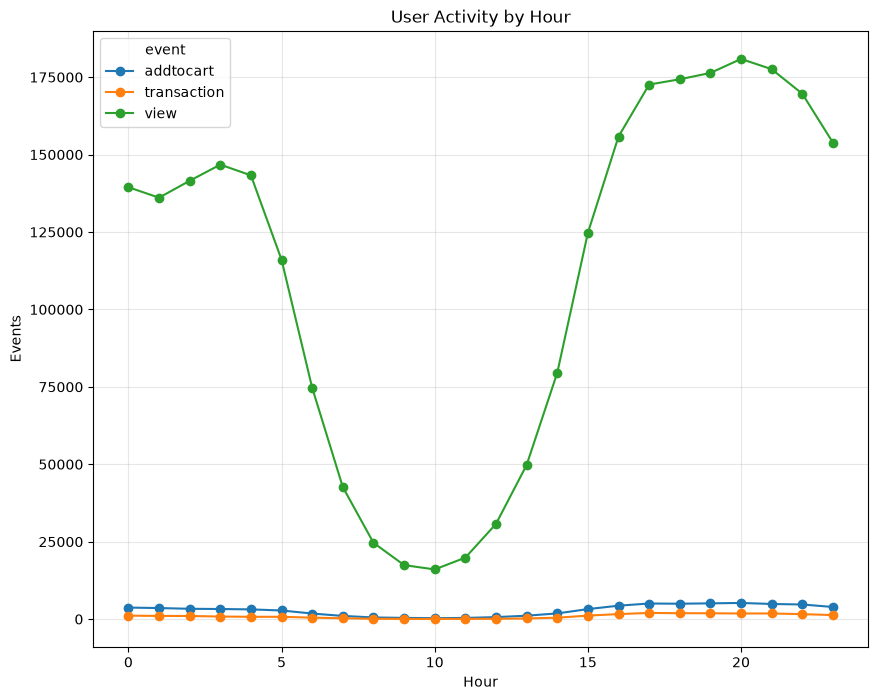

In [73]:
#plot
hourly_events.plot(figsize=(10,8),marker="o")

plt.title("User Activity by Hour")
plt.ylabel("Events")
plt.grid(alpha=0.3)
plt.savefig('User Activity by Hour.png',dpi=400)
plt.show()

In [74]:
#Purchases by Hour
purchase_hour = events[events["event"]=="transaction"]["Hour"].value_counts()
purchase_hour

Hour
17    2000
18    1907
19    1891
21    1829
20    1817
16    1621
22    1600
23    1311
15    1138
0     1119
1     1037
2     1012
3      836
5      747
4      747
6      477
14     455
7      278
13     215
8      106
12     103
11      84
9       70
10      57
Name: count, dtype: int64

/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_32087/2660413114.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purchase_hour, palette="icefire", )


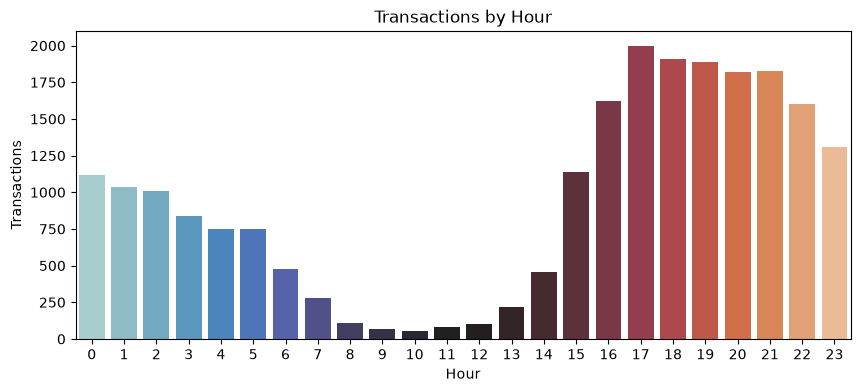

In [75]:
#plot
plt.figure(figsize=(10,4))
sns.barplot(data=purchase_hour, palette="icefire", )

plt.ylabel("Transactions")

plt.title("Transactions by Hour")
plt.savefig('Transactions by Hour.png',dpi=400)

plt.show()

In [76]:
#Views by Hour
view_hour = events[events["event"]=="view"]["Hour"].value_counts()
view_hour

Hour
20    180880
21    177577
19    176363
18    174320
17    172611
22    169633
16    155822
23    153853
3     146758
4     143296
2     141530
0     139459
1     136087
15    124721
5     116039
14     79524
6      74692
13     49768
7      42638
12     30736
8      24663
11     19857
9      17440
10     16045
Name: count, dtype: int64

/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_32087/1028166947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=view_hour, palette="coolwarm", )


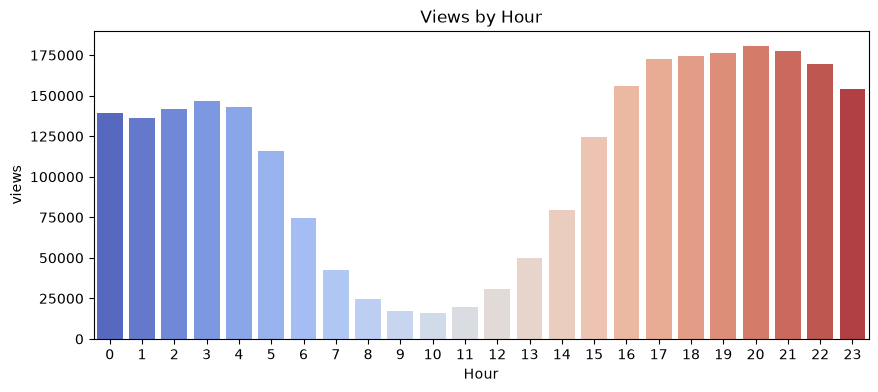

In [77]:
#plot
plt.figure(figsize=(10,4))
sns.barplot(data=view_hour, palette="coolwarm", )

plt.ylabel("views")

plt.title("Views by Hour")

plt.show()

In [78]:
#Add-to-Cart by Hour
cart_hour = events[events["event"]=="addtocart"]["Hour"].value_counts()
cart_hour

Hour
20    5222
19    5094
17    5040
18    4973
21    4891
22    4723
16    4341
23    3920
0     3725
1     3578
2     3337
3     3266
15    3233
4     3141
5     2786
14    1844
6     1803
13    1106
7     1028
12     647
8      540
9      399
11     389
10     306
Name: count, dtype: int64

/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_32087/4268911619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cart_hour, palette="coolwarm", )


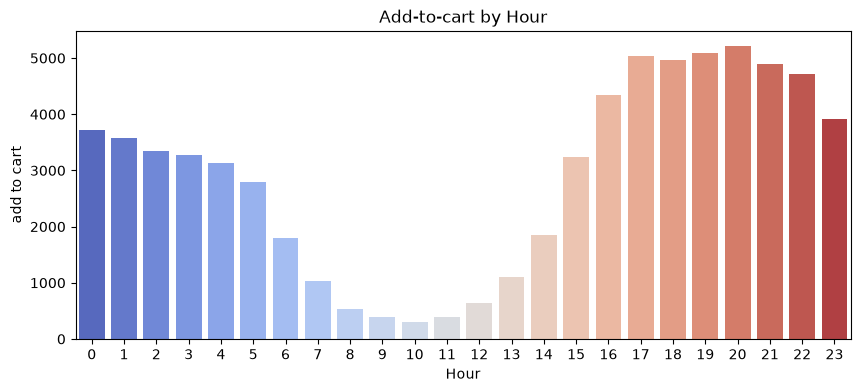

In [79]:
#plot
plt.figure(figsize=(10,4))
sns.barplot(data=cart_hour, palette="coolwarm", )

plt.ylabel("add to cart")

plt.title("Add-to-cart by Hour")
plt.savefig('Add-to-cart by Hour.png',dpi=400)

plt.show()

In [80]:
#Hourly Conversion
hourly =events.groupby(["Hour","event"]).size().unstack(fill_value=0)
hourly

event,addtocart,transaction,view
Hour,,,
0,3725,1119,139459
1,3578,1037,136087
2,3337,1012,141530
3,3266,836,146758
4,3141,747,143296
5,2786,747,116039
6,1803,477,74692
7,1028,278,42638
8,540,106,24663


In [81]:
hourly["View_to_Purchase_%"] = (hourly["transaction"] /hourly["view"] *100)
hourly.sort_values("View_to_Purchase_%",ascending=False)

event,addtocart,transaction,view,View_to_Purchase_%
Hour,,,,
17,5040,2000,172611,1.158675
18,4973,1907,174320,1.093965
19,5094,1891,176363,1.072220
16,4341,1621,155822,1.040290
21,4891,1829,177577,1.029976
20,5222,1817,180880,1.004533
22,4723,1600,169633,0.943213
15,3233,1138,124721,0.912437
23,3920,1311,153853,0.852112


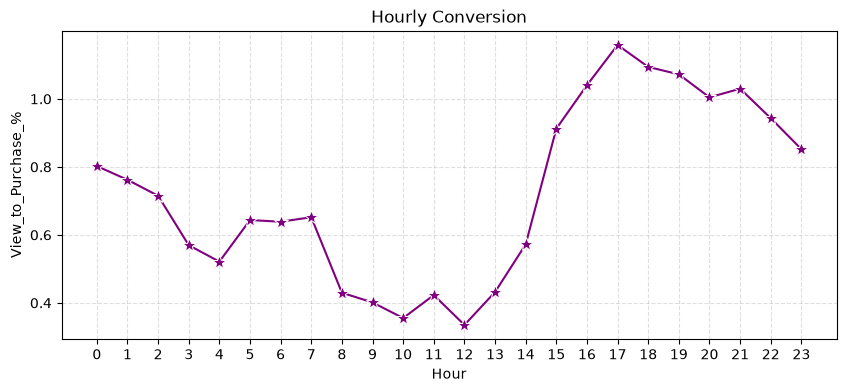

In [82]:
#plot
plt.figure(figsize=(10,4))
sns.lineplot(data=hourly,x='Hour',y='View_to_Purchase_%', color='purple',marker='*' ,markersize=10)
plt.grid(linestyle="--", alpha=0.4)
plt.ylabel("View_to_Purchase_%")
plt.xticks(np.arange(0,24,1))
plt.title("Hourly Conversion")
plt.savefig('Hourly Conversion.png',dpi=400)

plt.show()

In [83]:
#Weekday Analysis
weekday =events.groupby(["Weekday","event"]).size().unstack(fill_value=0)
weekday 

event,addtocart,transaction,view
Weekday,,,
Friday,9545,2929,367225
Monday,11371,3848,424594
Saturday,6949,1811,296455
Sunday,7547,1995,324880
Thursday,10951,3750,404060
Tuesday,11585,3973,431519
Wednesday,11384,4151,415579


In [84]:
weekday = weekday.reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
weekday

event,addtocart,transaction,view
Weekday,,,
Monday,11371,3848,424594
Tuesday,11585,3973,431519
Wednesday,11384,4151,415579
Thursday,10951,3750,404060
Friday,9545,2929,367225
Saturday,6949,1811,296455
Sunday,7547,1995,324880


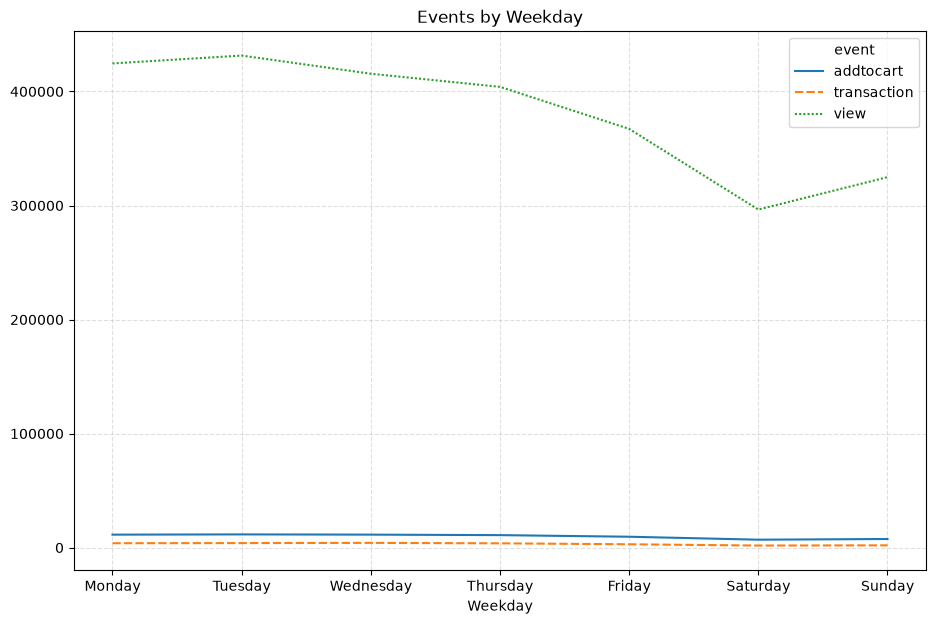

In [85]:
#plot
plt.figure(figsize=(11,7))
sns.lineplot(data=weekday)
plt.grid(linestyle="--", alpha=0.4)

plt.title("Events by Weekday")
plt.savefig('Events by Weekday.png',dpi=400)

plt.show()

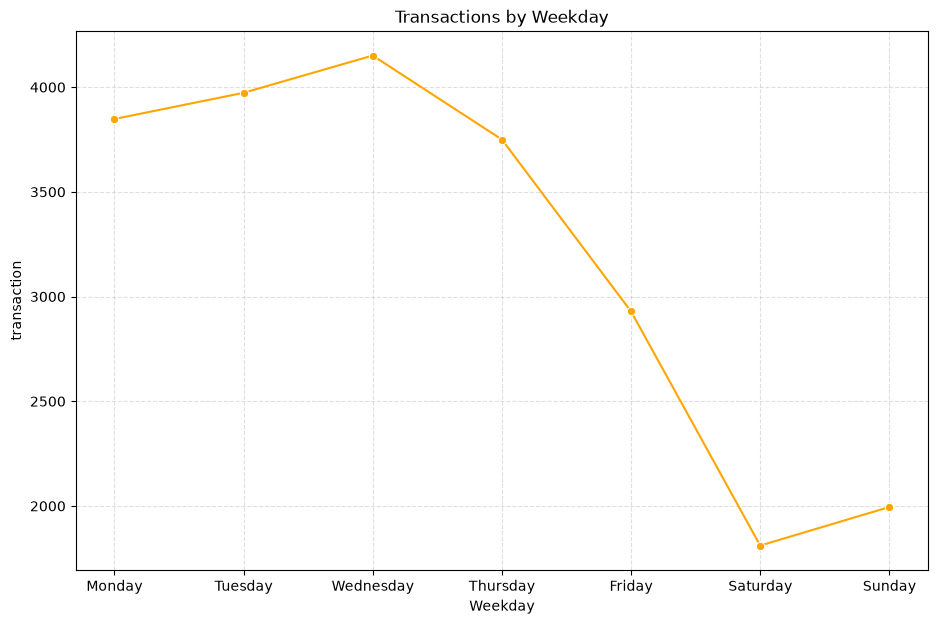

In [86]:
#plot
plt.figure(figsize=(11,7))
sns.lineplot(data=weekday,y='transaction',x='Weekday',marker='o', color='orange')
plt.grid(linestyle="--", alpha=0.4)

plt.title("Transactions by Weekday")
plt.savefig('Transactions by Weekday.png',dpi=400)
plt.show()

# Phase 8: Time-Based User Behavior Analysis

## Objective
Analyze how user activity changes across hours and weekdays to identify peak engagement periods, purchasing behavior, and optimal business timings.

---

## Hourly Behavior

### Peak Browsing Hours
| Hour | Views |
|------:|------:|
| 20:00 | 180,880 |
| 21:00 | 177,577 |
| 19:00 | 176,363 |
| 18:00 | 174,320 |
| 17:00 | 172,611 |

**Insights**
- User activity is heavily concentrated during the **evening (5 PM–10 PM)**.
- These hours receive the highest browsing traffic, making them ideal for promotions and product discovery.

---

### Peak Add-to-Cart Hours
| Hour | Add to Cart |
|------:|------------:|
| 20:00 | 5,222 |
| 19:00 | 5,094 |
| 17:00 | 5,040 |
| 18:00 | 4,973 |
| 21:00 | 4,891 |

**Insights**
- Cart additions closely follow browsing behavior.
- Evening visitors show stronger purchase intent compared to daytime users.

---

### Peak Purchase Hours
| Hour | Transactions |
|------:|-------------:|
| 17:00 | 2,000 |
| 18:00 | 1,907 |
| 19:00 | 1,891 |
| 21:00 | 1,829 |
| 20:00 | 1,817 |

**Insights**
- The highest number of purchases occurs between **5 PM and 9 PM**.
- This period represents the platform's primary revenue window.

---

## Hourly Conversion Analysis

Highest View-to-Purchase Conversion:

| Hour | Conversion (%) |
|------:|---------------:|
| 17:00 | 1.16 |
| 18:00 | 1.09 |
| 19:00 | 1.07 |
| 16:00 | 1.04 |
| 21:00 | 1.03 |

Lowest Conversion:

| Hour | Conversion (%) |
|------:|---------------:|
| 12:00 | 0.34 |
| 10:00 | 0.36 |
| 9:00 | 0.40 |

**Insights**
- Conversion nearly **triples** during the evening compared to late morning.
- Visitors arriving after work hours exhibit significantly higher buying intent.
- Morning traffic appears more exploratory, while evening traffic is purchase-oriented.

---

## Weekday Analysis

| Weekday | Views | Transactions |
|----------|------:|-------------:|
| Tuesday | 431,519 | 3,973 |
| Monday | 424,594 | 3,848 |
| Wednesday | 415,579 | **4,151** |
| Thursday | 404,060 | 3,750 |
| Friday | 367,225 | 2,929 |
| Saturday | 296,455 | 1,811 |
| Sunday | 324,880 | 1,995 |

**Insights**
- **Tuesday** attracts the highest browsing activity.
- **Wednesday** generates the highest number of completed purchases.
- User engagement declines noticeably during weekends, especially on Saturday.
- Weekdays consistently outperform weekends in both traffic and sales.

---

## Business Recommendations

- Schedule promotional campaigns, push notifications, and email marketing between **5 PM and 9 PM**, when purchase intent is highest.
- Allocate advertising budgets toward **weekday evenings**, particularly Tuesday and Wednesday.
- Consider running weekend-specific offers to compensate for lower weekend engagement.
- Prioritize system performance and customer support availability during evening peak hours to maximize conversion.

# Executive Summary

This project analyzed over **2.75 million e-commerce events** generated by **1.4 million visitors** to understand customer behavior across the complete purchase journey.

The analysis covered visitor engagement, category performance, buyer behavior, cart abandonment, and time-based purchasing patterns to identify conversion opportunities and provide actionable business recommendations.

# Key Business Findings

1. Nearly **99.8%** of visitors viewed products, but only **2.68%** added products to cart, revealing the largest conversion loss occurs between browsing and cart addition.

2. Only **0.83%** of all visitors completed a purchase, indicating substantial opportunity to improve conversion.

3. **Star Categories** generated both high traffic and high transactions, making them the platform's primary revenue drivers.

4. **Optimize Conversion** categories attracted strong visitor interest but converted poorly, representing the largest revenue optimization opportunity.

5. Several **Hidden Gem** categories achieved high purchase conversion despite relatively low traffic, suggesting they deserve greater exposure.

6. Approximately **72%** of visitors who added products to their cart abandoned before purchasing.

7. **78%** of buyers made only a single purchase, while only **22%** became repeat buyers.

8. Over **81%** of buyers purchased only one unique product, indicating limited cross-selling behavior.

9. Peak purchasing activity occurred between **5 PM and 9 PM**, when conversion rates were highest.

10. Tuesday generated the highest browsing activity, while Wednesday recorded the greatest number of completed purchases.

# Business Recommendations

## Improve View-to-Cart Conversion

- Optimize product pages for high-traffic, low-conversion categories.
- Improve product descriptions, pricing transparency, and product images.
- Surface customer reviews more prominently.

## Reduce Cart Abandonment

- Introduce abandoned cart reminders.
- Simplify checkout flow.
- Display shipping costs earlier in the purchase journey.

## Promote Hidden Gem Categories

- Feature high-converting categories on the homepage.
- Increase exposure through recommendations and search ranking.

## Increase Repeat Purchases

- Launch loyalty and rewards programs.
- Recommend complementary products after purchase.
- Personalize follow-up marketing campaigns.

## Optimize Marketing Timing

- Schedule campaigns during **5 PM–9 PM**.
- Focus promotional efforts on Tuesday and Wednesday when engagement and purchases are strongest.

# Business Impact

This analysis identifies multiple opportunities to improve customer conversion and revenue by:

- Increasing View-to-Cart conversion in high-traffic categories.
- Reducing cart abandonment.
- Promoting high-converting hidden categories.
- Encouraging repeat purchases.
- Optimizing campaign timing based on user behavior.

Together, these recommendations provide a data-driven roadmap for improving customer experience and maximizing business performance.

# Dashboard

The analytical findings from this project can be visualized through an interactive dashboard containing:

- Visitor Funnel
- Category Opportunity Matrix
- Buyer Segmentation
- Cart Abandonment Analysis
- Time-Based Activity
- Executive KPI Summary